# v1 — Đường cơ sở MIMIC PPG

> Ý tưởng đúng, cách chấm điểm sai. Một lỗi duy nhất, nhưng đủ để làm hỏng
> mọi con số về sau.

| | |
|---|---|
| Kênh tín hiệu | PPG |
| Cửa sổ | 30 giây, bước 30 giây (không chồng lấn) |
| Đặc trưng | 13 cột tuyến tính |
| Chia dữ liệu | ngẫu nhiên 80/20 theo cửa sổ ❌ |
| Mô hình | Random Forest |
| **Điểm công bố** | **95.2% → 95.9%** |

## 1. Ý tưởng gốc

Tâm nhĩ rung thì khoảng cách giữa các nhịp tim trở nên hỗn loạn. Đo sự hỗn
loạn đó bằng các chỉ số HRV rồi để máy học phân biệt.

Ý tưởng này **đúng** và sống sót qua cả 4 phiên bản. Cái sai nằm ở chỗ khác.

In [1]:
import os, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Notebook nam trong src/report/ -> thu muc goi la src/
CWD = os.path.abspath('')
SRC = os.path.dirname(CWD) if os.path.basename(CWD) == 'report' else CWD
if SRC not in sys.path:
    sys.path.insert(0, SRC)

from vlab import store, viz, honest
from vlab.extract import extract_table

pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 40)
%matplotlib inline
print('San sang. src =', SRC)


San sang. src = D:\Projects\HealthSense\HealthSense-MachineLearning-Lab\src


In [2]:
import v1
r = store.load('v1')
if r is None:
    r = v1.run()

print('Cấu hình v1:')
for k, val in r['config'].items():
    if k != 'features':
        print(f'  {k:12}: {val}')
print('\n13 đặc trưng:', ', '.join(r['config']['features']))

Cấu hình v1:
  channel     : PPG
  window_s    : 30.0
  step_s      : 30.0
  overlap_pct : 0.0
  n_features  : 13
  cleaning    : không
  scaling     : StandardScaler trong Pipeline (fit theo train)
  split       : ngẫu nhiên theo cửa sổ 80/20
  model       : Random Forest (100 cây)

13 đặc trưng: HR_mean, Mean_NN, SDNN, RMSSD, NN50, pNN50, CV, LF, HF, Total_Power, LF_HF_Ratio, LF_norm, HF_norm


## 2. Dữ liệu

35 bệnh nhân MIMIC PERform (19 AFib, 16 bình thường), mỗi người ~20 phút tín
hiệu PPG. Cắt thành cửa sổ 30 giây không chồng lấn → mỗi người đúng 40 cửa sổ.

In [3]:
df = extract_table('PPG', 30.0, 30.0, verbose=False)
print(f"{len(df)} cửa sổ / {df['record_id'].nunique()} bệnh nhân")
print(f"AFib: {(df['status']==1).sum()} cửa sổ | Bình thường: {(df['status']==0).sum()} cửa sổ")
print(f"Mỗi bệnh nhân đóng góp: {df.groupby('record_id').size().unique()} cửa sổ")
df.head(3)

1400 cửa sổ / 35 bệnh nhân
AFib: 760 cửa sổ | Bình thường: 640 cửa sổ
Mỗi bệnh nhân đóng góp: [40] cửa sổ


,record_id,t_start,status,HR_mean,Mean_NN,SDNN,RMSSD,NN50,pNN50,CV,LF,HF,Total_Power,LF_HF_Ratio,LF_norm,HF_norm,SD1,SD2,SampEn
0,mimic_perform_af_001,0.0,1,89.893762,667.454545,113.798160,175.906952,33,76.744186,0.170496,1380.362757,2706.838146,4728.340374,0.509954,33.772814,66.227186,125.855935,100.301175,1.945910
1,mimic_perform_af_001,30.0,1,91.216216,657.777778,102.689490,124.579292,25,56.818182,0.156116,1290.758617,2974.608225,4968.761887,0.433926,30.261374,69.738626,89.045111,114.722408,2.564949
2,mimic_perform_af_001,60.0,1,90.313085,664.355556,111.947462,166.704965,33,75.000000,0.168505,1593.676409,3846.645718,6764.882517,0.414303,29.293788,70.706212,119.218030,104.170677,0.000000


## 3. Điểm bản gốc — và bằng chứng của lỗi

Bản gốc trộn toàn bộ cửa sổ rồi bốc ngẫu nhiên 20% làm test. Hãy đếm xem có
bao nhiêu bệnh nhân trong test **cũng xuất hiện** trong train.

In [4]:
leaky = r['reproduced_leaky']
print(f"Accuracy khi chấm kiểu gốc : {leaky['accuracy']*100:.2f}%")
print(f"ROC-AUC                    : {leaky['roc_auc']:.4f}")
print()
print(f"Bệnh nhân trong tập test              : {leaky['n_test_subjects']}")
print(f"Trong đó cũng có mặt ở tập train      : {leaky['n_subjects_also_in_train']}")
print(f"Tỉ lệ chồng lấn                       : {leaky['subject_overlap_pct']}%")

Accuracy khi chấm kiểu gốc : 98.21%
ROC-AUC                    : 0.9968

Bệnh nhân trong tập test              : 35
Trong đó cũng có mặt ở tập train      : 35
Tỉ lệ chồng lấn                       : 100.0%


**100%.** Không sót một ai.

Mô hình không cần học "AFib trông như thế nào". Nó chỉ cần học "nhịp tim của
bác A trông như thế nào" — và bác A có mặt ở cả hai bên ranh giới.

Hãy nhìn cụ thể một bệnh nhân để thấy chuyện gì xảy ra:

In [5]:
from sklearn.model_selection import train_test_split
idx = np.arange(len(df))
tr, te = train_test_split(idx, test_size=0.2, random_state=42, stratify=df['status'])

vi_du = df['record_id'].iloc[te].value_counts().index[0]
n_train = int((df['record_id'].iloc[tr] == vi_du).sum())
n_test = int((df['record_id'].iloc[te] == vi_du).sum())
print(f'Ví dụ bệnh nhân: {vi_du}')
print(f'  {n_train} cửa sổ nằm trong TRAIN (mô hình được học)')
print(f'  {n_test} cửa sổ nằm trong TEST  (dùng để chấm điểm)')
print()
print(f'Mô hình đã nhìn thấy {n_train} đoạn nhịp của chính người này trước khi')
print(f'bị hỏi về {n_test} đoạn còn lại. Đó không phải là kiểm tra.')

Ví dụ bệnh nhân: mimic_perform_af_003
  26 cửa sổ nằm trong TRAIN (mô hình được học)
  14 cửa sổ nằm trong TEST  (dùng để chấm điểm)

Mô hình đã nhìn thấy 26 đoạn nhịp của chính người này trước khi
bị hỏi về 14 đoạn còn lại. Đó không phải là kiểm tra.


## 4. Chấm lại bằng LOSO

Bây giờ chấm trung thực: mỗi vòng giữ trọn một bệnh nhân ra ngoài, học trên
34 người còn lại, rồi hỏi về đúng người chưa từng gặp. Làm 35 vòng cho đủ
mọi người.

In [6]:
loso_w = r['regraded_loso_window']
loso_s = r['regraded_loso_subject']

so_sanh = pd.DataFrame([
    {'Cách chấm': 'Ngẫu nhiên theo cửa sổ (bản gốc)',
     'Accuracy': leaky['accuracy'], 'Recall': leaky['recall'],
     'Specificity': leaky['specificity'], 'ROC-AUC': leaky['roc_auc']},
    {'Cách chấm': 'LOSO theo bệnh nhân (trung thực)',
     'Accuracy': loso_w['accuracy'], 'Recall': loso_w['recall'],
     'Specificity': loso_w['specificity'], 'ROC-AUC': loso_w['roc_auc']},
])
so_sanh

,Cách chấm,Accuracy,Recall,Specificity,ROC-AUC
0,Ngẫu nhiên theo cửa sổ (bản gốc),0.9821,1.0000,0.9609,0.9968
1,LOSO theo bệnh nhân (trung thực),0.9207,0.9684,0.8641,0.9431


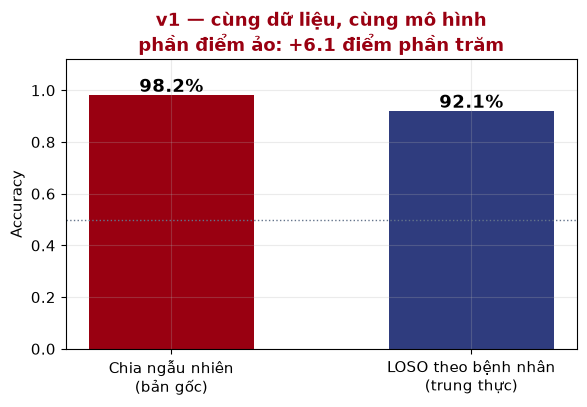

In [7]:
fig = viz.leakage_gap(leaky['accuracy'], loso_w['accuracy'],
                      title='v1 — cùng dữ liệu, cùng mô hình')
plt.show()

### Cột nào tụt nhiều nhất?

Để ý **Specificity** — tỉ lệ nhận đúng người bình thường. Nó tụt mạnh hơn
Recall rất nhiều.

Ý nghĩa thực tế: mô hình vẫn bắt được hầu hết ca AFib, nhưng **báo động giả
nhiều hơn hẳn** so với những gì bản gốc tưởng. Với một sản phẩm sàng lọc,
báo động giả tràn lan là lý do người dùng tháo vòng ra và không đeo nữa.

## 5. Nhìn ở mức bệnh nhân

Mức cửa sổ trả lời "đoạn 30 giây này có bất thường không?". Nhưng câu hỏi
thật của bác sĩ là "**người này** có bị AFib không?".

Gộp toàn bộ cửa sổ của mỗi người thành một điểm số duy nhất:

Mức bệnh nhân (LOSO): 35 người
  Accuracy    : 94.29%
  Recall      : 100.00%  (bắt được bao nhiêu ca AFib)
  Specificity : 87.50%  (không báo oan người thường)


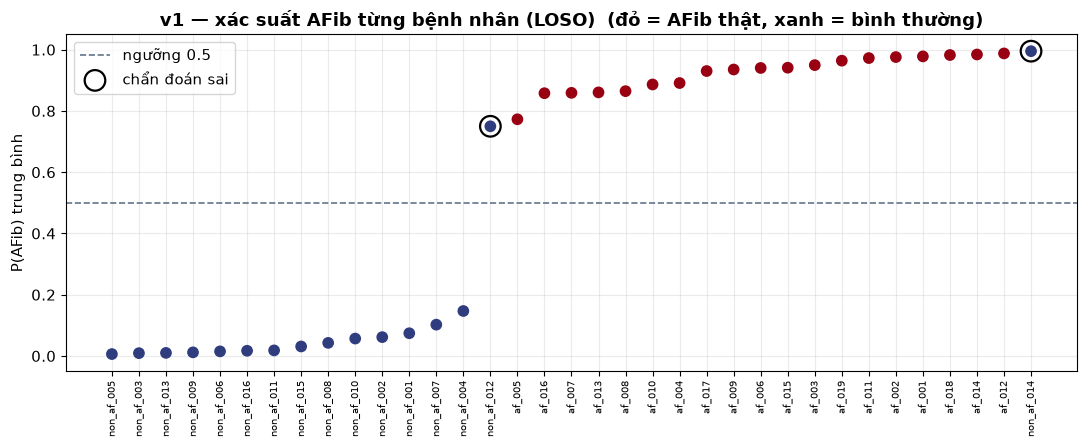

In [8]:
print(f"Mức bệnh nhân (LOSO): {loso_s['n_subjects']} người")
print(f"  Accuracy    : {loso_s['accuracy']*100:.2f}%")
print(f"  Recall      : {loso_s['recall']*100:.2f}%  (bắt được bao nhiêu ca AFib)")
print(f"  Specificity : {loso_s['specificity']*100:.2f}%  (không báo oan người thường)")

fig = viz.subject_probabilities(
    {'subjects': r['subject_detail']['subjects'],
     'subject_proba': r['subject_detail']['proba'],
     'subject_true': r['subject_detail']['true']},
    title='v1 — xác suất AFib từng bệnh nhân (LOSO)')
plt.show()

Mỗi chấm là một bệnh nhân. Đỏ = AFib thật, xanh = bình thường. Chấm bị
khoanh đen là ca chẩn đoán sai.

Điều đáng chú ý: điểm mức bệnh nhân **cao hơn** mức cửa sổ. Lý do rất tự
nhiên — một người có 40 cửa sổ, sai vài cửa sổ vẫn không đổi kết luận cuối
cùng. Đây là lập luận ủng hộ việc đo nhiều lần rồi tổng hợp, thay vì tin vào
một lần đo 30 giây.

## 6. Bài học rút ra

1. **Ý tưởng của v1 đúng.** HRV thật sự phân biệt được AFib — điều này giữ
   nguyên đến tận sản phẩm.
2. **Cái sai là ranh giới train/test.** Chỉ một dòng `train_test_split` mà
   thổi phồng kết quả hơn 6 điểm phần trăm.
3. **Dấu hiệu để tự nghi ngờ:** nếu dữ liệu của bạn có nhiều dòng thuộc về
   cùng một "đối tượng" (bệnh nhân, người dùng, thiết bị, phiên đo) thì chia
   ngẫu nhiên theo dòng gần như luôn sai. Phải chia theo **đối tượng**.

Ghi chú lịch sử đáng suy ngẫm: nhánh thử nghiệm trước đó trên bộ MIT-BIH
có bảng đặc trưng **kèm sẵn cột `record`** —
tức danh tính bệnh nhân. Dòng huấn luyện lại chủ động `drop` cột đó rồi chia
ngẫu nhiên. Công cụ để làm đúng đã nằm trong tay ngay từ đầu.

➡️ Tiếp theo: [`02_v2_report.ipynb`](02_v2_report.ipynb) — nhóm phát hiện mô hình
sai vài ca, và quyết định... xóa những ca đó đi.